## Step 1: Import Libraries & Load Data

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../dataSet/Africa Data v1.0.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (203125, 16)


,fnid,country,country_code,admin_1,admin_2,product,season_name,planting_year,planting_month,harvest_year,harvest_month,crop_production_system,qc_flag,area,production,yield
0,AO2008A101,Angola,AO,Bengo,none,Banana,Main,2007,10,2008,4,All (PS),0,1364.0,19588.0,14.360704
1,AO2008A101,Angola,AO,Bengo,none,Banana,Main,2008,10,2009,4,All (PS),0,1364.0,20461.0,15.000733
2,AO2008A101,Angola,AO,Bengo,none,Banana,Main,2014,10,2015,4,All (PS),0,8706.0,222044.0,25.504709
3,AO2008A101,Angola,AO,Bengo,none,Banana,Main,2015,10,2016,4,All (PS),0,8706.0,222044.0,25.504709
4,AO2008A101,Angola,AO,Bengo,none,Banana,Main,2016,10,2017,4,All (PS),0,9549.7,233967.0,24.499932


## Step 2: Data Exploration

In [40]:
print("Data Types:")
print(df.dtypes)
print("\nSummary:")
df.describe()


Data Types:
fnid                       object
country                    object
country_code               object
admin_1                    object
admin_2                    object
product                    object
season_name                object
planting_year               int64
planting_month              int64
harvest_year                int64
harvest_month               int64
crop_production_system     object
qc_flag                     int64
area                      float64
production                float64
yield                     float64
dtype: object

Summary:


,planting_year,planting_month,harvest_year,harvest_month,qc_flag,area,production,yield
count,203125.000000,203125.000000,203125.000000,203125.000000,203125.000000,1.904280e+05,1.983460e+05,185430.000000
mean,2005.638257,6.007074,2005.968039,8.452736,0.027490,3.282292e+04,4.014160e+04,3.632818
std,10.613502,3.118320,10.664340,3.615595,0.226541,4.091427e+06,2.086109e+05,12.292582
min,1960.000000,1.000000,1960.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000047
25%,2000.000000,3.000000,2000.000000,5.000000,0.000000,2.000000e+02,2.746701e+02,0.541429
50%,2007.000000,6.000000,2008.000000,10.000000,0.000000,1.855000e+03,2.248000e+03,0.985439
75%,2014.000000,9.000000,2014.000000,12.000000,0.000000,1.207900e+04,1.552912e+04,2.700000
max,2024.000000,11.000000,2024.000000,12.000000,2.000000,1.751414e+09,8.899134e+06,1229.428571


In [41]:
print("Missing Values: ")
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")
print(f"Rows with missing yield: {df['yield'].isnull().sum()} ({df['yield'].isnull().mean()*100:.1f}%)")

Missing Values: 
fnid                          0
country                       0
country_code                  0
admin_1                       0
admin_2                       0
product                       0
season_name                   0
planting_year                 0
planting_month                0
harvest_year                  0
harvest_month                 0
crop_production_system        0
qc_flag                       0
area                      12697
production                 4779
yield                     17695
dtype: int64

Total rows: 203125
Rows with missing yield: 17695 (8.7%)


In [42]:
print("Unique Values in Categorical Columns")
for col in ['country', 'product', 'season_name', 'crop_production_system']:
    print(f"  {col}: {df[col].nunique()} unique values")
    print(f"    Top 5: {df[col].value_counts().head().index.tolist()}")

Unique Values in Categorical Columns
  country: 33 unique values
    Top 5: ['Benin', 'Niger', 'Burkina Faso', 'Ethiopia', 'Kenya']
  product: 94 unique values
    Top 5: ['Maize', 'Sorghum', 'Millet', 'Groundnuts (In Shell)', 'Rice']
  season_name: 33 unique values
    Top 5: ['Main', 'Annual', 'Meher', 'Wet', 'Dry']
  crop_production_system: 27 unique values
    Top 5: ['All (PS)', 'none', 'Rainfed (PS)', 'irrigated', 'Commercial (PS)']


## Step 3: Data Visualization

Meaningful visualizations to understand feature relationships and guide model training.

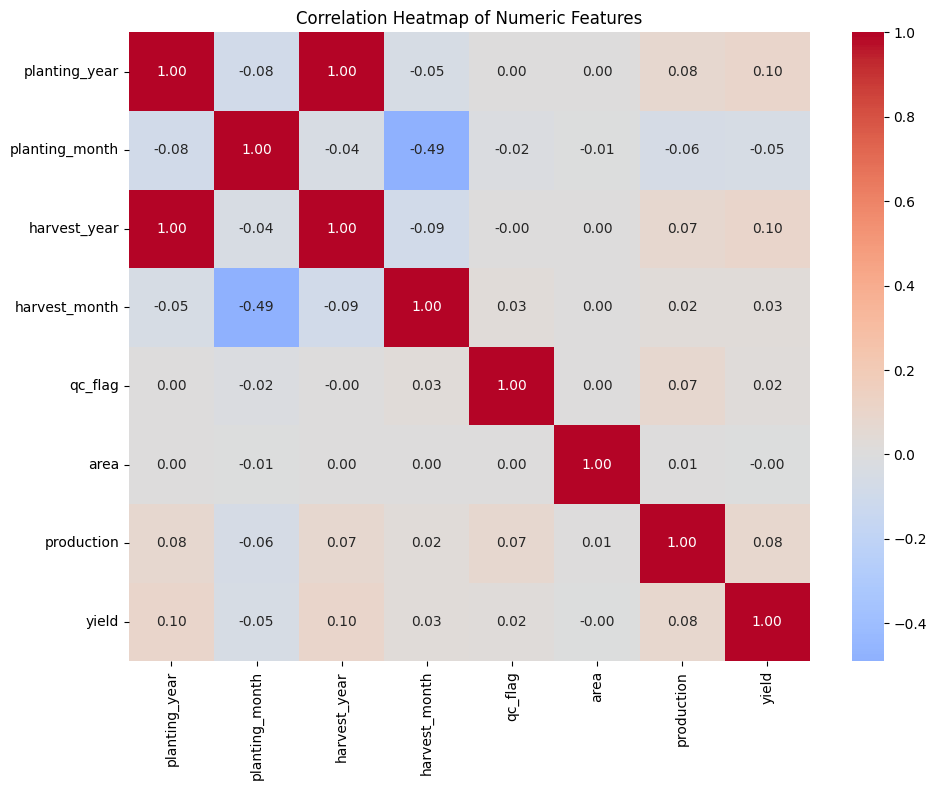


Interpretation: The heatmap shows how numeric features relate to each other.
- 'area' and 'production' are strongly correlated (more land = more production).
- 'yield' has a weaker correlation with 'area', meaning yield depends on other factors like crop type and farming method.


In [43]:
# Visualization 1: Correlation Heatmap of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

print("\nInterpretation: The heatmap shows how numeric features relate to each other.")
print("- 'area' and 'production' are strongly correlated (more land = more production).")
print("- 'yield' has a weaker correlation with 'area', meaning yield depends on other factors like crop type and farming method.")

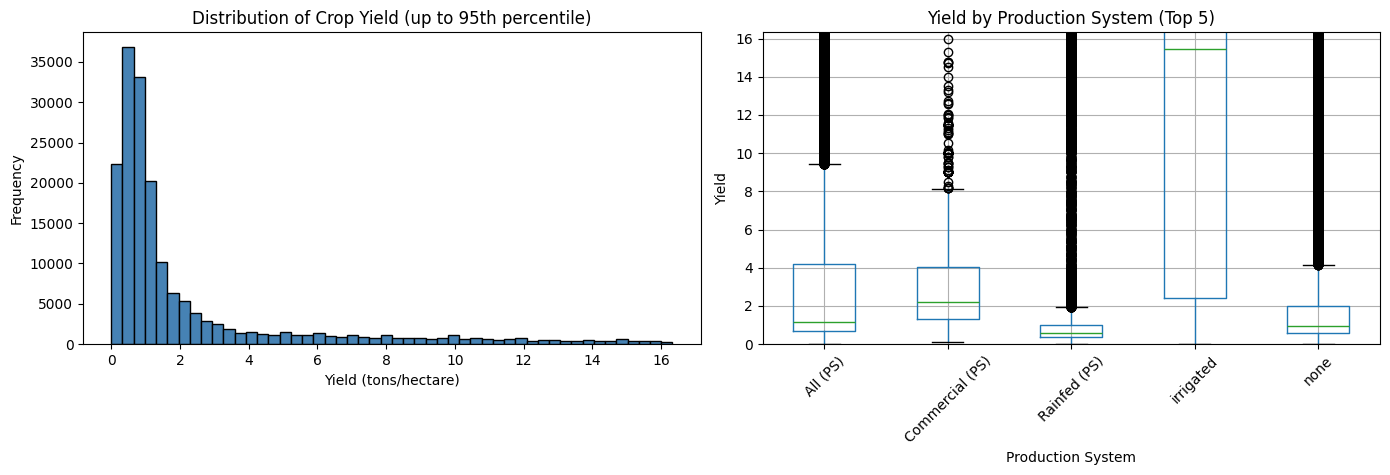


Interpretation:
- Yield distribution is right-skewed - most crops have low-to-moderate yield.
- Different production systems produce different yield ranges, confirming that farming method impacts productivity.


In [44]:
# Visualization 2: Distribution of Yield by Production System
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yield_cap = df['yield'].quantile(0.95)
axes[0].hist(df['yield'][df['yield'] <= yield_cap].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Crop Yield (up to 95th percentile)')
axes[0].set_xlabel('Yield (tons/hectare)')
axes[0].set_ylabel('Frequency')

top_systems = df['crop_production_system'].value_counts().head(5).index
df_top = df[df['crop_production_system'].isin(top_systems)]
df_top.boxplot(column='yield', by='crop_production_system', ax=axes[1], rot=45)
axes[1].set_title('Yield by Production System (Top 5)')
axes[1].set_xlabel('Production System')
axes[1].set_ylabel('Yield')
axes[1].set_ylim(0, yield_cap)
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Yield distribution is right-skewed - most crops have low-to-moderate yield.")
print("- Different production systems produce different yield ranges, confirming that farming method impacts productivity.")

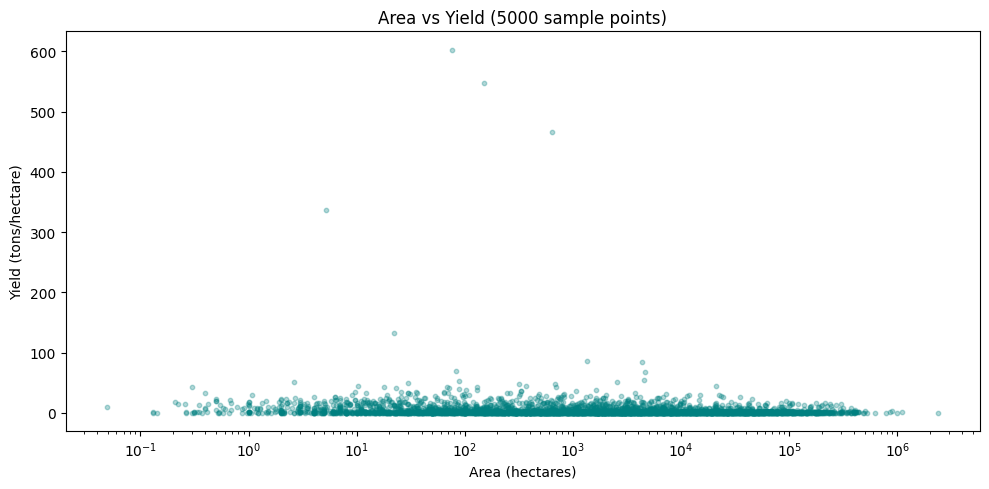


Interpretation: No strong linear pattern between area and yield.
This suggests yield depends more on crop type, region, and farming method than just land size.


In [45]:
# Visualization 3: Scatter plot - Area vs Yield
plt.figure(figsize=(10, 5))
sample = df.dropna(subset=['area', 'yield']).sample(5000, random_state=42)
plt.scatter(sample['area'], sample['yield'], alpha=0.3, s=10, color='teal')
plt.xlabel('Area (hectares)')
plt.ylabel('Yield (tons/hectare)')
plt.title('Area vs Yield (5000 sample points)')
plt.xscale('log')
plt.tight_layout()
plt.show()

print("\nInterpretation: No strong linear pattern between area and yield.")
print("This suggests yield depends more on crop type, region, and farming method than just land size.")

## Step 4: Feature Engineering

Selecting, transforming, and encoding features for modeling.

In [46]:
# Drop columns that are not useful for prediction
# - fnid: unique identifier, no predictive value
# - country_code: redundant with country
# - admin_2: too many unique values (707) and many are 'none'
# - qc_flag: quality control flag, not a real feature
# - production: directly derived from area * yield (would cause data leakage)

columns_to_drop = ['fnid', 'country_code', 'admin_2', 'qc_flag', 'production']
df_clean = df.drop(columns=columns_to_drop)
print(f"Columns dropped: {columns_to_drop}")
print(f"Remaining columns: {df_clean.columns.tolist()}")
print(f"\nShape after dropping columns: {df_clean.shape}")

# Drop rows where the target variable (yield) or area is missing
df_clean = df_clean.dropna(subset=['yield', 'area'])
print(f"Shape after dropping missing yield/area: {df_clean.shape}")

# Remove rows with zero area (invalid records)
df_clean = df_clean[df_clean['area'] > 0]
print(f"Shape after removing zero-area rows: {df_clean.shape}")

# Remove outliers in yield (above 95th percentile) and area (above 99th percentile)
yield_95 = df_clean['yield'].quantile(0.95)
area_99 = df_clean['area'].quantile(0.99)
df_clean = df_clean[df_clean['yield'] <= yield_95]
df_clean = df_clean[df_clean['area'] <= area_99]
print(f"Shape after removing outliers (yield>{yield_95:.2f}, area>{area_99:.0f}): {df_clean.shape}")

# Convert categorical columns to numeric using Label Encoding
categorical_cols = ['country', 'admin_1', 'product', 'season_name', 'crop_production_system']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"Encoded '{col}': {len(le.classes_)} categories")

print("\nAll categorical columns converted to numeric.")

# Feature Engineering: create new meaningful features
df_clean['grow_duration'] = (df_clean['harvest_month'] - df_clean['planting_month']).apply(lambda x: x + 12 if x < 0 else x)
df_clean['log_area'] = np.log1p(df_clean['area'])
print("Added 'grow_duration' (months from planting to harvest)")
print("Added 'log_area' (log-transformed area to handle large range)")

# Define features (X) and target (y)
X = df_clean.drop(columns=['yield'])
y = df_clean['yield']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features used: {X.columns.tolist()}")

# Standardize the features
feature_columns = X.columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeatures standardized (mean=0, std=1)")

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Columns dropped: ['fnid', 'country_code', 'admin_2', 'qc_flag', 'production']
Remaining columns: ['country', 'admin_1', 'product', 'season_name', 'planting_year', 'planting_month', 'harvest_year', 'harvest_month', 'crop_production_system', 'area', 'yield']

Shape after dropping columns: (203125, 11)
Shape after dropping missing yield/area: (185430, 11)
Shape after removing zero-area rows: (185430, 11)
Shape after removing outliers (yield>16.33, area>287294): (174313, 11)
Encoded 'country': 32 categories
Encoded 'admin_1': 409 categories
Encoded 'product': 93 categories
Encoded 'season_name': 33 categories
Encoded 'crop_production_system': 27 categories

All categorical columns converted to numeric.
Added 'grow_duration' (months from planting to harvest)
Added 'log_area' (log-transformed area to handle large range)

Features shape: (174313, 12)
Target shape: (174313,)
Features used: ['country', 'admin_1', 'product', 'season_name', 'planting_year', 'planting_month', 'harvest_year', 'harv

## Step 5: Model Training

Training three models: Linear Regression (with gradient descent), Decision Tree, and Random Forest.

In [47]:
# Model 1: Linear Regression using SGDRegressor (gradient descent)
sgd_model = SGDRegressor(max_iter=1000, tol=1e-4, eta0=0.0001, learning_rate='invscaling', 
                         penalty='l2', alpha=0.001, random_state=42)
sgd_model.fit(X_train, y_train)

# Track loss over epochs using partial_fit for the loss curve
sgd_curve = SGDRegressor(max_iter=1, tol=None, eta0=0.0001, learning_rate='invscaling', 
                         penalty='l2', alpha=0.001, random_state=42, warm_start=True)

n_epochs = 50
train_losses_sgd = []
test_losses_sgd = []

for epoch in range(n_epochs):
    sgd_curve.partial_fit(X_train, y_train)
    train_losses_sgd.append(mean_squared_error(y_train, sgd_curve.predict(X_train)))
    test_losses_sgd.append(mean_squared_error(y_test, sgd_curve.predict(X_test)))

sgd_train_mse = mean_squared_error(y_train, sgd_model.predict(X_train))
sgd_test_mse = mean_squared_error(y_test, sgd_model.predict(X_test))

print("SGD Linear Regression trained!")
print(f"  Train MSE: {sgd_train_mse:.4f}")
print(f"  Test MSE: {sgd_test_mse:.4f}")
print(f"  Test R2: {r2_score(y_test, sgd_model.predict(X_test)):.4f}")

SGD Linear Regression trained!
  Train MSE: 9.3928
  Test MSE: 9.4483
  Test R2: 0.1291


In [48]:
# Standard Linear Regression (closed-form solution)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_train_mse = mean_squared_error(y_train, lr_model.predict(X_train))
lr_test_mse = mean_squared_error(y_test, lr_model.predict(X_test))

print("Linear Regression (closed-form) trained!")
print(f"  Train MSE: {lr_train_mse:.4f}")
print(f"  Test MSE: {lr_test_mse:.4f}")
print(f"  Test R2: {r2_score(y_test, lr_model.predict(X_test)):.4f}")

Linear Regression (closed-form) trained!
  Train MSE: 9.0627
  Test MSE: 9.0726
  Test R2: 0.1637


In [49]:
# Model 2: Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=20, min_samples_leaf=2, random_state=42)
dt_model.fit(X_train, y_train)

dt_train_mse = mean_squared_error(y_train, dt_model.predict(X_train))
dt_test_mse = mean_squared_error(y_test, dt_model.predict(X_test))

print("Decision Tree trained!")
print(f"  Train MSE: {dt_train_mse:.4f}")
print(f"  Test MSE: {dt_test_mse:.4f}")
print(f"  Test R2: {r2_score(y_test, dt_model.predict(X_test)):.4f}")

Decision Tree trained!
  Train MSE: 0.5663
  Test MSE: 1.9797
  Test R2: 0.8175


In [50]:
# Model 3: Random Forest Regressor (optimized)
rf_model = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_split=5, 
                                  min_samples_leaf=1, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_train_mse = mean_squared_error(y_train, rf_model.predict(X_train))
rf_test_mse = mean_squared_error(y_test, rf_model.predict(X_test))

print("Random Forest trained!")
print(f"  Train MSE: {rf_train_mse:.4f}")
print(f"  Test MSE: {rf_test_mse:.4f}")
print(f"  Test R2: {r2_score(y_test, rf_model.predict(X_test)):.4f}")

Random Forest trained!
  Train MSE: 0.3560
  Test MSE: 1.3551
  Test R2: 0.8751


## Step 6: Loss Curves

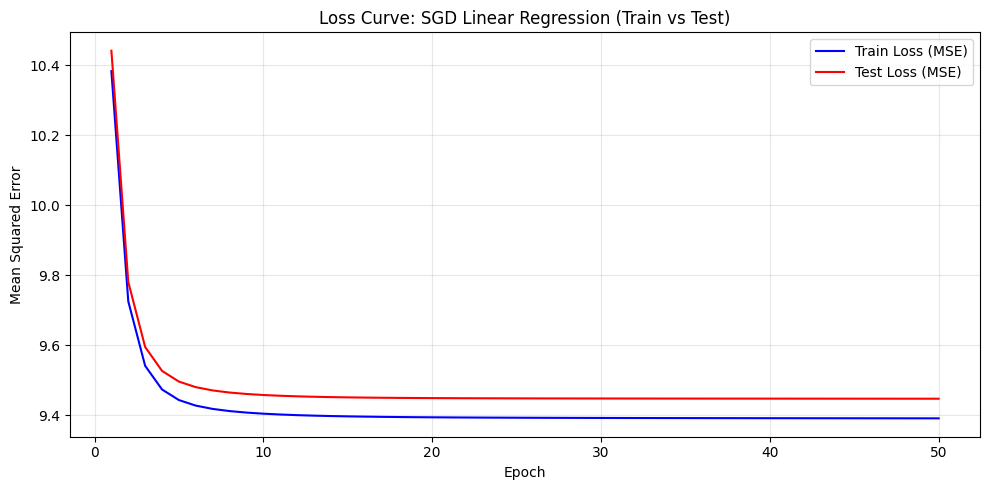

The loss curve shows how the model error decreases over training epochs.
Both train and test loss converge, indicating the model is learning without overfitting.


In [51]:
# Plot loss curve for SGD Linear Regression (train vs test)
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_losses_sgd, label='Train Loss (MSE)', color='blue')
plt.plot(range(1, n_epochs + 1), test_losses_sgd, label='Test Loss (MSE)', color='red')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Loss Curve: SGD Linear Regression (Train vs Test)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The loss curve shows how the model error decreases over training epochs.")
print("Both train and test loss converge, indicating the model is learning without overfitting.")

## Step 7: Model Comparison

In [52]:
# Compare all models
models = {
    'Linear Regression (SGD)': (sgd_model, sgd_test_mse),
    'Linear Regression (Closed-form)': (lr_model, lr_test_mse),
    'Decision Tree': (dt_model, dt_test_mse),
    'Random Forest': (rf_model, rf_test_mse)
}

print(" Model Comparison (Test MSE) ")
print(f"{'Model':<35} {'Test MSE':<15} {'Test R2':<10}")
print("-" * 60)
for name, (model, mse) in models.items():
    r2 = r2_score(y_test, model.predict(X_test))
    print(f"{name:<35} {mse:<15.4f} {r2:<10.4f}")

# Find best model (lowest test MSE)
best_name = min(models, key=lambda k: models[k][1])
best_model = models[best_name][0]
best_mse = models[best_name][1]
print(f"\nBest model: {best_name} (Test MSE: {best_mse:.4f})")

 Model Comparison (Test MSE) 
Model                               Test MSE        Test R2   
------------------------------------------------------------
Linear Regression (SGD)             9.4483          0.1291    
Linear Regression (Closed-form)     9.0726          0.1637    
Decision Tree                       1.9797          0.8175    
Random Forest                       1.3551          0.8751    

Best model: Random Forest (Test MSE: 1.3551)


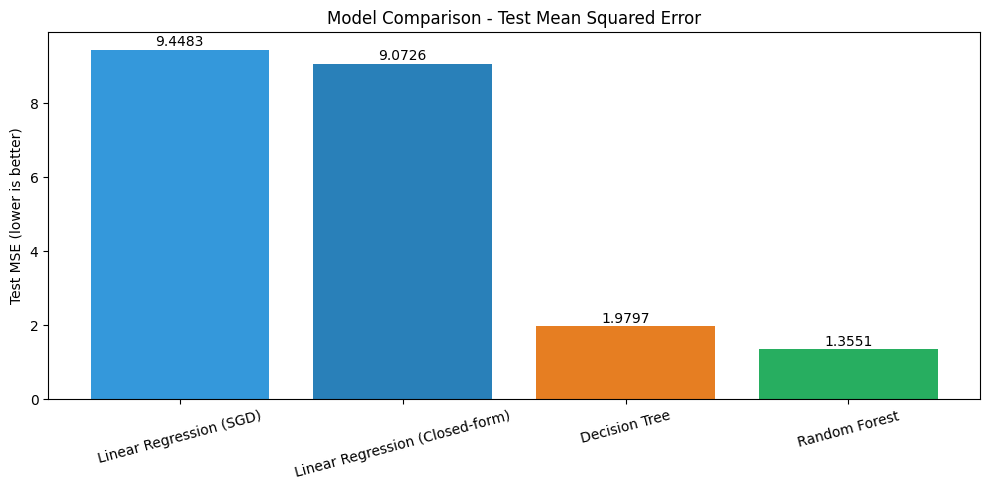

In [53]:
# Bar chart of model performance
model_names = list(models.keys())
test_mses = [models[name][1] for name in model_names]

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, test_mses, color=['#3498db', '#2980b9', '#e67e22', '#27ae60'])
plt.ylabel('Test MSE (lower is better)')
plt.title('Model Comparison - Test Mean Squared Error')
plt.xticks(rotation=15)
for bar, mse in zip(bars, test_mses):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{mse:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Step 8: Scatter Plot - Before and After (Linear Regression Line)

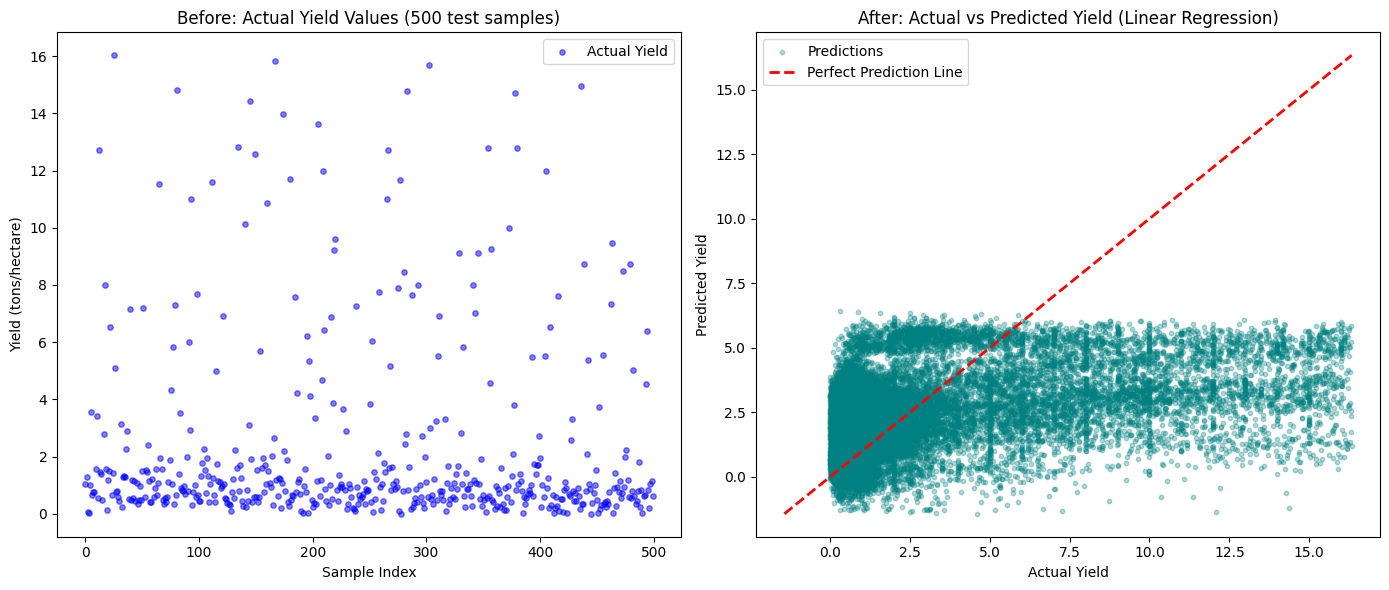

The scatter plot shows how the linear regression predictions compare to actual values.
Points closer to the red dashed line indicate more accurate predictions.


In [54]:
# Scatter plot: Actual vs Predicted with the linear regression line
y_pred_lr = lr_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before: Actual data scatter
axes[0].scatter(range(len(y_test[:500])), y_test.values[:500], alpha=0.5, s=15, color='blue', label='Actual Yield')
axes[0].set_title('Before: Actual Yield Values (500 test samples)')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Yield (tons/hectare)')
axes[0].legend()

# After: Actual vs Predicted with regression line
axes[1].scatter(y_test, y_pred_lr, alpha=0.3, s=10, color='teal', label='Predictions')
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction Line')
axes[1].set_title('After: Actual vs Predicted Yield (Linear Regression)')
axes[1].set_xlabel('Actual Yield')
axes[1].set_ylabel('Predicted Yield')
axes[1].legend()

plt.tight_layout()
plt.show()

print("The scatter plot shows how the linear regression predictions compare to actual values.")
print("Points closer to the red dashed line indicate more accurate predictions.")

## Step 9: Save the Best Model (Compressed for Deployment)

Retrain with fewer trees (50 instead of 300) and save with compression to reduce file size for deployment.

In [55]:
# Retrain Random Forest with fewer trees + max compression for deployment
rf_small = RandomForestRegressor(n_estimators=25, max_depth=25, min_samples_split=5, 
                                  min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_small.fit(X_train, y_train)

rf_small_train_mse = mean_squared_error(y_train, rf_small.predict(X_train))
rf_small_test_mse = mean_squared_error(y_test, rf_small.predict(X_test))
rf_small_test_r2 = r2_score(y_test, rf_small.predict(X_test))

print(f"Compressed Random Forest (25 trees, depth=25):")
print(f"  Train MSE: {rf_small_train_mse:.4f}")
print(f"  Test MSE: {rf_small_test_mse:.4f}")
print(f"  Test R2: {rf_small_test_r2:.4f}")
print(f"\nOriginal RF (25 trees) - Test MSE: {rf_test_mse:.4f}, R2: {r2_score(y_test, rf_model.predict(X_test)):.4f}")

# Save with max compression for deployment
best_model = rf_small
joblib.dump(best_model, 'best_model.pkl', compress=9)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

import os
size_mb = os.path.getsize('best_model.pkl') / (1024 * 1024)
print(f"\nModel saved with max compression. Size: {size_mb:.1f} MB")
print("Scaler, label encoders, and feature columns saved.")

Compressed Random Forest (25 trees, depth=25):
  Train MSE: 0.5024
  Test MSE: 1.3886
  Test R2: 0.8720

Original RF (25 trees) - Test MSE: 1.3551, R2: 0.8751

Model saved with max compression. Size: 30.2 MB
Scaler, label encoders, and feature columns saved.


## Step 10: Prediction on a Single Data Point

In [56]:
# Make a prediction on one row from the test data
sample_index = 0
sample_input = X_test[sample_index].reshape(1, -1)
actual_value = y_test.iloc[sample_index]

predicted_value = best_model.predict(sample_input)[0]

print(f"Actual Yield: {actual_value:.4f} tons/hectare")
print(f"Predicted Yield: {predicted_value:.4f} tons/hectare")
print(f"Difference: {abs(actual_value - predicted_value):.4f} tons/hectare")

Actual Yield: 1.0533 tons/hectare
Predicted Yield: 1.0367 tons/hectare
Difference: 0.0166 tons/hectare


## Step 11: Prediction Script

This function can be used to make predictions with new data (will be used in Task 2 - API).

In [57]:
def predict_yield(country, admin_1, product, season_name, crop_production_system,
                  planting_year, planting_month, harvest_year, harvest_month, area):
    """
    Predict crop yield given farming conditions.
    Returns predicted yield in tons/hectare.
    """
    # Calculate engineered features
    grow_duration = harvest_month - planting_month
    if grow_duration < 0:
        grow_duration += 12
    log_area = np.log1p(area)
    
    # Encode categorical features
    input_dict = {
        'country': label_encoders['country'].transform([country])[0],
        'admin_1': label_encoders['admin_1'].transform([admin_1])[0],
        'product': label_encoders['product'].transform([product])[0],
        'season_name': label_encoders['season_name'].transform([season_name])[0],
        'crop_production_system': label_encoders['crop_production_system'].transform([crop_production_system])[0],
        'planting_year': planting_year,
        'planting_month': planting_month,
        'harvest_year': harvest_year,
        'harvest_month': harvest_month,
        'area': area,
        'grow_duration': grow_duration,
        'log_area': log_area
    }
    
    # Ensure correct column order, scale, and predict
    input_array = np.array([[input_dict[col] for col in feature_columns]])
    input_scaled = scaler.transform(input_array)
    prediction = best_model.predict(input_scaled)[0]
    return prediction

# Example usage with valid values from the dataset
result = predict_yield(
    country='Kenya',
    admin_1='Mombasa',
    product='Maize',
    season_name='Annual',
    crop_production_system='All (PS)',
    planting_year=2015,
    planting_month=3,
    harvest_year=2015,
    harvest_month=8,
    area=5000
)
print(f"Predicted yield for Maize in Mombasa, Kenya: {result:.4f} tons/hectare")

Predicted yield for Maize in Mombasa, Kenya: 1.2979 tons/hectare
